In [2]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import xarray as xr
import sys

sys.path.append("..")  # Adds higher directory to python modules path.
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

In [3]:
folder = "/media/jbeckwith/Ezra Seagat/JSB/20250414_CellPAINT/data/+cholesterol_cell1/"

In [4]:
file = "HILO_40perc_515_515lp_650200bp_50ms_1_MMStack_Default.ome.tif"

In [5]:
data = IO.read_tiff(os.path.join(folder, file))

<tifffile.TiffFile 'HILO_40perc_515…_Default.ome.tif'> MMStack series is missing files. Returning subset (1, 1730, 1, 1) of (1, 50000, 1, 1)


In [6]:
mip = np.max(data[50:, :, :], axis=0)

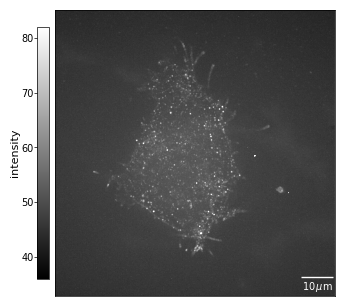

In [37]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs=axs, data=mip[100:1200, 300:-200], cbarlabel="intensity")

folder_tosave = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250424/fig/multicolour/cell_PAINT/"
plt.savefig(os.path.join(folder_tosave, "Example_MIP.svg"), dpi=600, format="svg")

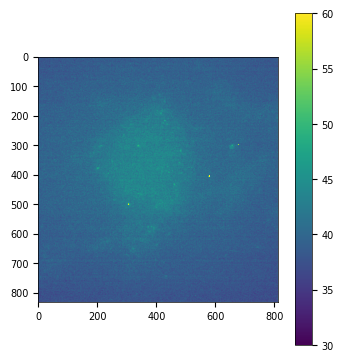

In [35]:
plt.imshow(data[200, 100:1200, 300:-200], vmin=30, vmax=60)
plt.colorbar()

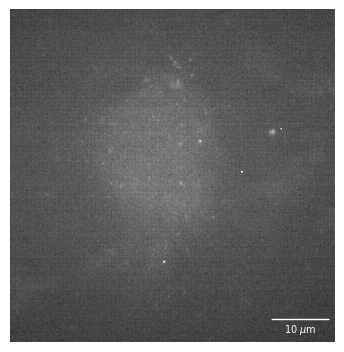

In [7]:
folder_tosave = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250424/fig/multicolour/cell_PAINT/"
filename = "Example_GIF.gif"
n_frames = 100
plotter.make_animated_gif_image(
    data[50 : n_frames + 50, 100:1200, 300:-200],
    n_frames,
    os.path.join(folder_tosave, filename),
    vmin=30,
    vmax=60,
    pixelsize=69,
    scalebarsize=10000,
    scalebarlabel=r"10 $\mu$m",
    cbarlabel="intensity",
    cbar=False,
)

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1, 1])

axs[0] = plotter.image_plot(
    axs=axs[0],
    data=data[665:685, 135:155, 10],
    scalebarlabel="300 nm",
    scalebarsize=300,
    cbarlabel="intensity",
    vmax=190,
    vmin=127,
)

x = np.linspace(0, 396 * 0.1, 396)
y = np.mean(np.mean(data[665:685, 135:155, 4:400], axis=0), axis=0)

axs[0] = plotter.line_plot(
    axs=axs[1], x=x, y=y, xaxislabel="time / s", yaxislabel="punctum intensity"
)
plt.show()
# folder_tosave = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Patents/Figures'
# plt.savefig(os.path.join(folder_tosave, 'Example_Rh6G.svg'), dpi=600, format='svg')

In [ ]:
plt.imshow(data[665:685, 135:155, 205])
plt.colorbar()

In [ ]:
plt.plot(np.sum(np.sum(data[665:685, 135:155, 4:400], axis=0), axis=0))

In [ ]:
folder_analysis = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20241216/data"
file_680 = "fitter_WLS_fit_dye_option1_error_Smoothed_CF680_69_pixelsize_1p49_NA_RMSE_mean_bootstrapping.csv"
file_633 = "fitter_WLS_fit_dye_option1_error_Smoothed_CF633_69_pixelsize_1p49_NA_RMSE_mean_bootstrapping.csv"
analysis_data_633 = pl.read_csv(os.path.join(folder_analysis, file_633))
analysis_data_680 = pl.read_csv(os.path.join(folder_analysis, file_680))

In [ ]:
CF633_spectrum = S_F.get_dye_or_filter_data(
    dye_or_filter=True, names="CF633", wavelength=np.arange(400, 900)
)
CF680_spectrum = S_F.get_dye_or_filter_data(
    dye_or_filter=True, names="CF680", wavelength=np.arange(400, 900)
)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.line_plot(
    axs=axs,
    x=np.arange(400, 900),
    y=np.squeeze(CF633_spectrum) / np.max(CF633_spectrum),
    color="red",
    label="CF633",
)
axs = plotter.line_plot(
    axs=axs,
    x=np.arange(400, 900),
    y=np.squeeze(CF680_spectrum) / np.max(CF680_spectrum),
    color="darkred",
    label="CF680",
    xaxislabel="wavelength/nm",
    yaxislabel="fluorescence/normalised",
)
axs.set_xlim([550, 850])
axs.set_ylim([0, 1.05])
axs.legend(loc="best")
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250130/fig/multicolour_camera/dye_unmixing"
plt.savefig(os.path.join(folder, "CFdyes.svg"), dpi=600, format="svg")

In [ ]:
analysis_data_633

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.scatter_plot(
    axs=axs,
    x=analysis_data_633["n_photons"].to_numpy(),
    y=100 * analysis_data_633["dye"].to_numpy(),
    edgecolor="red",
    label="CF633",
)
axs = plotter.scatter_plot(
    axs=axs,
    x=analysis_data_680["n_photons"].to_numpy(),
    y=100 * analysis_data_680["dye"].to_numpy(),
    edgecolor="darkred",
    xaxislabel="number of photons",
    yaxislabel="error %",
    label="CF680",
)
axs.set_yscale("log")
axs.set_ylim([1e-2, 30])
axs.set_xscale("log")
axs.legend(loc="best")
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250130/fig/multicolour_camera/dye_unmixing"
plt.savefig(os.path.join(folder, "dye_picking_algorithm.svg"), dpi=600, format="svg")

In [ ]:
folder_analysis = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20241216/data"
file_633_1 = "fitter_WLS_fit_dye_option1_error_Smoothed_CF633_69_pixelsize_1p49_NA_RMSE_mean_bootstrapping.csv"
file_633_2 = "fitter_WLS_fit_dye_option2_error_Smoothed_CF633_69_pixelsize_1p49_NA_RMSE_mean_bootstrapping.csv"
file_633_3 = "fitter_WLS_fit_dye_option3_error_Smoothed_CF633_69_pixelsize_1p49_NA_RMSE_mean_bootstrapping.csv"
analysis_data_opt1 = pl.read_csv(os.path.join(folder_analysis, file_633_1))
analysis_data_opt2 = pl.read_csv(os.path.join(folder_analysis, file_633_2))
analysis_data_opt3 = pl.read_csv(os.path.join(folder_analysis, file_633_3))

file_680_1 = "fitter_WLS_fit_dye_option1_error_Smoothed_CF680_69_pixelsize_1p49_NA_RMSE_mean_bootstrapping.csv"
file_680_2 = "fitter_WLS_fit_dye_option2_error_Smoothed_CF680_69_pixelsize_1p49_NA_RMSE_mean_bootstrapping.csv"
file_680_3 = "fitter_WLS_fit_dye_option3_error_Smoothed_CF680_69_pixelsize_1p49_NA_RMSE_mean_bootstrapping.csv"
analysis_data_opt1_680 = pl.read_csv(os.path.join(folder_analysis, file_680_1))
analysis_data_opt2_680 = pl.read_csv(os.path.join(folder_analysis, file_680_2))
analysis_data_opt3_680 = pl.read_csv(os.path.join(folder_analysis, file_680_3))

In [ ]:
fig, axs = plotter.one_column_plot()

y1 = (
    100 * analysis_data_opt1["dye"].to_numpy()
    + 100 * analysis_data_opt1_680["dye"].to_numpy()
) / 2
y2 = (
    100 * analysis_data_opt2["dye"].to_numpy()
    + 100 * analysis_data_opt2_680["dye"].to_numpy()
) / 2
y3 = (
    100 * analysis_data_opt3["dye"].to_numpy()
    + 100 * analysis_data_opt3_680["dye"].to_numpy()
) / 2

axs = plotter.scatter_plot(
    axs=axs,
    x=analysis_data_opt1["n_photons"].to_numpy(),
    y=y1,
    edgecolor="darkred",
    label="Algo. 1",
)
axs = plotter.scatter_plot(
    axs=axs,
    x=analysis_data_opt2["n_photons"].to_numpy(),
    y=y2,
    edgecolor="red",
    label="Algo. 2",
)
axs = plotter.scatter_plot(
    axs=axs,
    x=analysis_data_opt3["n_photons"].to_numpy(),
    y=y3,
    edgecolor="darkgreen",
    xaxislabel="number of photons",
    yaxislabel="error %",
    label="Algo. 3",
)
axs.set_yscale("log")
axs.set_ylim([1e-2, 30])
axs.set_xscale("log")
axs.legend(loc="best")
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250130/fig/multicolour_camera/dye_unmixing"
plt.savefig(
    os.path.join(folder, "dye_picking_algorithm_comparison_mean.svg"),
    dpi=600,
    format="svg",
)

In [ ]:
folder_read = "/media/jbeckwith/Ezra Seagat/JSB/20250114/data/20250114"

In [ ]:
subfolder = "Bleached_Area_plusCy3_plusBHQ2_MiSeqChip_7perc561_1"
file = (
    "Bleached_Area_plusCy3_plusBHQ2_MiSeqChip_7perc561_1_MMStack_9-Pos000_001.ome.tif"
)
image = IO.read_tiff(os.path.join(folder_read, subfolder, file))
image = np.swapaxes(image, 0, 2)
image = image[:, :, :, 1]

In [ ]:
plt.imshow(image[:, :, 2])
plt.colorbar()

In [ ]:
nframes = 100
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250130/fig/RNA_on_a_miseq"
filename = "WithCy3+BHQ2_bleached.gif"
cbarlabel = "intensity per 100 ms"
label = r"MiSeq chip + Cy3 + BHQ2, 561 nm exc., 53 W/cm$^2$"
plotter.make_animated_gif_image(
    image,
    n_frames=nframes,
    filename=os.path.join(folder, filename),
    vmin=90,
    vmax=140,
    label=label,
    cbarlabel=cbarlabel,
    pixelsize=110,
    scalebarsize=10000,
    scalebarlabel=r"10 $\mu$m",
    fontsz=5,
)

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
analysis_folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/20250114/metadata/"
files = [
    "Bleached_Area_MiSeqChip_40perc561_1.csv",
    "Bleached_Area_MiSeqChip_40perc561_2.csv",
    "Bleached_Area_MiSeqChip_40perc561_3.csv",
    "Bleached_Area_MiSeqChip_40perc561_4.csv",
]

In [ ]:
bleached_data = None
for file in files:
    if bleached_data is None:
        bleached_data = pl.read_csv(os.path.join(analysis_folder, file))
    else:
        bleached_data = pl.concat(
            [bleached_data, pl.read_csv(os.path.join(analysis_folder, file))]
        )

In [ ]:
files = [
    "Unbleached_Area_MiSeqChip_20perc561_1.csv",
    "Unbleached_Area_MiSeqChip_20perc561_2.csv",
    "Unbleached_Area_MiSeqChip_20perc561_3.csv",
    "Unbleached_Area_MiSeqChip_20perc561_4.csv",
]

In [ ]:
unbleached_data = None
for file in files:
    if unbleached_data is None:
        unbleached_data = pl.read_csv(os.path.join(analysis_folder, file))
    else:
        unbleached_data = pl.concat(
            [unbleached_data, pl.read_csv(os.path.join(analysis_folder, file))]
        )

In [ ]:
fig, axs = plotter.one_column_plot()
data = bleached_data["intensity [photon]"].to_numpy()
data = data[data < 10000]
axs = plotter.histogram_plot(
    axs=axs,
    data=data,
    bins=np.histogram_bin_edges(data, bins="fd"),
    density=False,
    xaxislabel="photons per punctum",
)

data = unbleached_data["intensity [photon]"].to_numpy()
data = data[data < 20000]
axs = plotter.histogram_plot(
    axs=axs,
    data=data,
    bins=np.histogram_bin_edges(data, bins="fd"),
    density=False,
    xaxislabel="photons per punctum",
    alpha=0.5,
    histcolor="darkred",
)

axs.set_xlim([0, 2000])
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250130/fig/RNA_on_a_miseq"
filename = "Bleaching_Effect.svg"
plt.savefig(os.path.join(folder, filename), dpi=600, format="svg")
plt.show()

In [ ]:
flag = 4

if flag == 1:
    data_folder = (
        "/media/jbeckwith/Ezra Seagat/JSB/20241126/data/20241126_QDot565_210mW488_100ms"
    )
    metadata_folder = "/media/jbeckwith/Ezra Seagat/JSB/20241126/metadata/"
elif flag == 0:
    data_folder = (
        "/media/jbeckwith/Ezra Seagat/JSB/20241126/data/20241126_QDot565_210mW488_20ms"
    )
    metadata_folder = "/media/jbeckwith/Ezra Seagat/JSB/20241126/metadata/"
elif flag == 2:
    data_folder = (
        "/media/jbeckwith/Ezra Seagat/JSB/20241211/data/20241211_QD655_30perc515"
    )
    metadata_folder = "/media/jbeckwith/Ezra Seagat/JSB/20241211/metadata/"
elif flag == 3:
    data_folder = "/media/jbeckwith/Ezra Seagat/JSB/20241211/data/20241211_QD655_35perc515_2Mercaptoethanol"
    metadata_folder = "/media/jbeckwith/Ezra Seagat/JSB/20241211/metadata/"
elif flag == 4:
    data_folder = (
        "/media/jbeckwith/Ezra Seagat/JSB/20241211/data/20241211_QD705_100perc515"
    )
    metadata_folder = "/media/jbeckwith/Ezra Seagat/JSB/20241211/metadata/"
data_files = np.sort(os.listdir(data_folder))

calibration_folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration"
gain = IO.read_tiff(os.path.join(calibration_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(calibration_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(calibration_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(calibration_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(calibration_folder, "rqe.tif"))

masks = MSF.MF.get_masks(MSF.mosaic_unit, gain.shape[0], gain.shape[1])
masks_3d = np.dstack([masks["maskR"], masks["maskG"], masks["maskB"]])

x_coord, y_coord, width, height = IO.metadata_reader(
    os.path.join(metadata_folder, "CS505CU_100ms.json")
)
x_coord = x_coord - 1
y_coord = y_coord - 1

gain = gain[x_coord : x_coord + width, y_coord : y_coord + height]
offset = offset[x_coord : x_coord + width, y_coord : y_coord + height]
variance = variance[x_coord : x_coord + width, y_coord : y_coord + height]
readnoise = readnoise[x_coord : x_coord + width, y_coord : y_coord + height]
rqe = rqe[x_coord : x_coord + width, y_coord : y_coord + height]
masks_3d = masks_3d[x_coord : x_coord + width, y_coord : y_coord + height, :]

In [ ]:
raw_data, image, smoothed_data, weights_map = IO.read_tiff_tophotoelectrons(
    os.path.join(data_folder, data_files[0]),
    gain_map=gain,
    offset_map=offset,
    variance_map=variance,
    rqe=rqe,
    read_noise=readnoise,
)

In [ ]:
fig, ax = plotter.one_column_plot()

ax = plotter.image_plot(axs=ax, data=image[530:560, 510:540, 60])

plt.show()

In [ ]:
coords_20ms = ((350, 380), (270, 300))
coords_100ms = ((670, 700), (555, 585))
coords_flag2 = ((625, 655), (630, 660))
coords_flag3 = ((455, 485), (415, 445))
coords_flag4 = ((530, 560), (510, 540))

if flag == 0:
    tval = 100
elif flag == 1:
    tval = 12
elif flag == 2:
    tval = 0
elif flag == 3:
    tval = 0
elif flag == 4:
    tval = 60
image = image[:, :, tval:]
weights_map = weights_map[:, :, tval:]

if flag == 0:
    x_0 = coords_20ms[0][0]
    x_1 = coords_20ms[0][1]
    y_0 = coords_20ms[1][0]
    y_1 = coords_20ms[1][1]
elif flag == 1:
    x_0 = coords_100ms[0][0]
    x_1 = coords_100ms[0][1]
    y_0 = coords_100ms[1][0]
    y_1 = coords_100ms[1][1]
elif flag == 2:
    x_0 = coords_flag2[0][0]
    x_1 = coords_flag2[0][1]
    y_0 = coords_flag2[1][0]
    y_1 = coords_flag2[1][1]
elif flag == 3:
    x_0 = coords_flag3[0][0]
    x_1 = coords_flag3[0][1]
    y_0 = coords_flag3[1][0]
    y_1 = coords_flag3[1][1]
elif flag == 4:
    x_0 = coords_flag4[0][0]
    x_1 = coords_flag4[0][1]
    y_0 = coords_flag4[1][0]
    y_1 = coords_flag4[1][1]

image_1qd = image[x_0:x_1, y_0:y_1, :]
weights_1qd = weights_map[x_0:x_1, y_0:y_1, :]

In [ ]:
gain = gain[x_0:x_1, y_0:y_1]
offset = offset[x_0:x_1, y_0:y_1]
variance = variance[x_0:x_1, y_0:y_1]
readnoise = readnoise[x_0:x_1, y_0:y_1]
rqe = rqe[x_0:x_1, y_0:y_1]
masks_3d = masks_3d[x_0:x_1, y_0:y_1, :]

In [ ]:
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20241212/fig/multicolour_camera/QDs"
if flag == 1:
    filename = "Example_QD_100ms.gif"
    vmax = 400
    cbarlabel = "# of photoelectrons per 100 ms"
    label = r"QD585, 488 nm excitation, 4 kW/cm$^2$"
    nframes = 100
elif flag == 0:
    filename = "Example_QD_20ms.gif"
    vmax = 140
    cbarlabel = "# of photoelectrons per 20 ms"
    label = r"QD585, 488 nm excitation, 4 kW/cm$^2$"
    nframes = 100
elif flag == 2:
    filename = "Example_QD655_100ms.gif"
    vmax = 600
    cbarlabel = "# of photoelectrons per 100 ms"
    label = r"QD655, 515 nm excitation, 2 kW/cm$^2$"
    nframes = 500
elif flag == 3:
    filename = "Example_QD655_100ms_2Mercaptoethanol.gif"
    vmax = 220
    cbarlabel = "# of photoelectrons per 100 ms"
    label = r"QD655 + 140 mM 2-Mercaptoethanol"
    nframes = 500
elif flag == 4:
    filename = "Example_QD705_100ms.gif"
    vmax = 600
    cbarlabel = "# of photoelectrons per 100 ms"
    label = r"QD705, 515 nm excitation, 4.4 kW/cm$^2$"
    nframes = 500
plotter.make_animated_gif_image(
    image_1qd - np.median(image_1qd, axis=-1)[:, :, np.newaxis],
    n_frames=nframes,
    filename=os.path.join(folder, filename),
    vmin=0,
    vmax=vmax,
    label=label,
    cbarlabel=cbarlabel,
)

In [ ]:
SNR = (
    np.max(np.max(image_1qd, axis=1), axis=0)
    / np.max(np.max(image_1qd, axis=1), axis=0)[-1]
)

In [ ]:
fits = np.zeros([30, 30, image_1qd.shape[-1]])

In [ ]:
fit_parameters = np.zeros([8, image_1qd.shape[-1]])

for frame in np.arange(image_1qd.shape[-1]):
    if SNR[frame] > 2:
        xc_ig, yc_ig = np.unravel_index(
            np.argmax(
                sCMOS.var_weighted_uniform_filter(
                    image_1qd[:, :, frame] - np.median(image_1qd, axis=-1), variance, 4
                )
            ),
            image_1qd[:, :, frame].shape,
        )
        A = np.sum(
            np.abs(
                sCMOS.var_weighted_uniform_filter(
                    image_1qd[:, :, frame] - np.median(image_1qd, axis=-1), variance, 4
                )
            )
        )
        sigma = 2
        b = 0
        initial_guess = np.array([xc_ig, yc_ig, A, sigma, b, 0.5, 0.5, 0.5])
        result = I_AF.WLS_fit(
            image_1qd[:, :, frame] - np.median(image_1qd, axis=-1),
            initial_guess,
            masks=masks_3d,
            weights=weights_1qd[:, :, frame],
            display=False,
        )
        fits[:, :, frame] = I_AF.WLS_model(result.x, image_1qd[:, :, frame], masks_3d)
        fit_parameters[:, frame] = result.x

In [ ]:
plt.imshow(fits[:, :, 20])

In [ ]:
plt.imshow(image_1qd[:, :, 20] - np.median(image_1qd, axis=-1))

In [ ]:
plt.plot(fit_parameters[5, :200], color="r")
plt.plot(fit_parameters[6, :200], color="g")
plt.plot(fit_parameters[7, :200], color="b")

In [ ]:
fig, ax = plotter.one_column_plot()

ax = plotter.line_plot(
    axs=ax,
    x=(np.arange(image_1qd.shape[-1]) * 100) / 1000,
    y=SNR,
    yaxislabel="SNR",
    xaxislabel="time / s",
)
ax.set_xlim([1, 20])
ax.set_ylim([1, 20])

plt.tight_layout()
plt.savefig(
    "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20241212/fig/multicolour_camera/QDs/20ms_SNR.svg",
    format="svg",
    dpi=600,
)

In [ ]:
signal = np.sum(np.sum(image_1qd, axis=1), axis=0)

In [ ]:
model = "l2"  # "l1", "rbf", "linear", "normal", "ar",...
algo = rpt.Binseg(model=model).fit(signal)

In [ ]:
sigma = np.std(signal)

In [ ]:
my_bkps = algo.predict(pen=np.log(image_1qd.shape[-1]) * 1 * sigma**2)

In [ ]:
my_bkps

In [ ]:
plt.plot((np.arange(image_1qd.shape[-1]) * 20) / 1000, signal)
for bkp in my_bkps:
    plt.vlines(x=bkp * (20 / 1000), ymin=0, ymax=28000, ls="--", color="k", lw=0.5)
plt.ylim(14500, 28000)

In [ ]:
import fpbase
import numpy as np

In [ ]:
wavelength = np.arange(200, 1100)

In [ ]:
R, G, B, wavelength = S_F.getpixelefficiency()
wavelength = wavelength
pixel_QYs = np.vstack([R, G, B])

In [ ]:
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        ["Qdot 705", "Qdot 585"], [], wavelength, pixel_QYs
    )
)

In [ ]:
np.array(dye_pixel_efficiency.T / np.sum(dye_pixel_efficiency, axis=1)).T

In [ ]:
PSF.sigma_PSF(average_emission_wavelengths, 1.49)

In [ ]:
spectra = S_F.get_dye_or_filter_data(
    ["semrock-blp01-488r-25", "semrock-blp01-532r"],
    wavelength=wavelength,
    dye_or_filter=False,
)

In [ ]:
import types

fitter = types.SimpleNamespace()
fitter.fit_function = I_AF.WLS_fit
fitter.default_params = np.array(["xc", "yc", "A", "sigma", "b", "R", "G", "B"])
fitter.error_type = "Smoothed"

In [ ]:
fitter.fit_function(
    np.zeros([10, 10]), np.zeros(8), np.zeros([10, 10, 3]), np.ones([10, 10])
)

In [ ]:
A = ["B", "G", "R"]

In [ ]:
index = A.index("R")
index

In [ ]:
x.default_params

In [ ]:
dye = S_F.get_dye_or_filter_data(["Rhodamine 6G", "Qdot 705"], wavelength=wavelength)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(wavelength, spectra.T, lw=0.5)
plt.plot(wavelength, dye.T / np.max(dye), color="k")
# plt.plot(wavelength, np.dot(dye, spectra))
plt.show(block=False)

In [ ]:
dye_at_detector_spectra = np.array(
    np.multiply(dye, np.prod(spectra, axis=0)).T
    / np.sum(np.multiply(dye, np.prod(spectra, axis=0)), axis=1)
).T
plt.plot(wavelength, dye_at_detector_spectra.T)

In [ ]:
average_emission_wavelengths = np.trapz(
    y=wavelength
    * (dye_at_detector_spectra.T / np.trapz(x=wavelength, y=dye_at_detector_spectra)).T,
    x=wavelength,
)

In [ ]:
plt.plot(wavelength, spectra.T)

In [ ]:
plt.plot(wavelength, np.prod(spectra, axis=0))

In [ ]:
filter = fpbase.get_filter("Semrock NF03-405/488/561/635E")

In [ ]:
np.array(filter.spectrum.data)

In [ ]:
a = ["test"]

In [ ]:
len([0, 1, 2])

In [ ]:
dye_pixel_efficiency / np.sum(dye_pixel_efficiency)